# **Previsão da Capacidade Instalada de Usinas Elétricas com Regressão Supervisionada**
*Atividade Avaliativa Final*

Fatec Jundiaí - Ciência de dados – Inteligência Computacional<br>
Prof. Me. Mateus Guilherme Fuini

Discente: Enrico Sablich Aoyama | RA: 1141352513022

---
Este notebook desenvolve uma solução completa de Ciência de Dados utilizando Python e Scikit-learn. O objetivo é prever a capacidade instalada de uma usina elétrica, em megawatts (`capacity_mw`), com base em atributos geográficos, técnicos e categóricos do dataset **Global Power Plant Database**, disponível pelo Kaggle no link: https://www.kaggle.com/datasets/ranafayezz/global-power-plant/data<br>

Repositório do projeto: https://github.com/EnricoAoyama/fatec_intcomp_prjfinal<br>

---
## 1- Objetivo do projeto
O objetivo é construir um fluxo organizado de Machine Learning para prever a capacidade instalada de usinas elétricas no mundo.

A variável alvo será:
*   `capacity_mw`: capacidade instalada da usina, em megawatts.

Este problema foi formulado como **regressão**, pois a variável alvo é numérica contínua.

Além da modelagem, o projeto contempla:
* análise exploratória de dados;
* tratamento de valores ausentes;
* identificação e tratamento de outliers;
* transformação de variáveis categóricas;
* escalonamento de atributos numéricos;
* engenharia de atributos;
* divisão treino/teste;
* uso de Pipeline e ColumnTransformer;
* prevenção de data leakage;
* validação com K-Fold Cross Validation;
* otimização de hiperparâmetros com GridSearchCV;
* avaliação com métricas de regressão.

---
## 2- Sobre o dataset
O dataset utilizado é o **Global Power Plant Database**, disponível no Kaggle no link:

https://www.kaggle.com/datasets/ranafayezz/global-power-plant

Ele contém informações sobre usinas elétricas em diferentes países, incluindo localização, capacidade instalada, fonte primária de energia, ano de comissionamento, proprietário e dados de geração.

O dataset atende aos requisitos da atividade porque possui:

* mais de 500 registros;
* valores ausentes;
* variáveis categóricas;
* variáveis numéricas;
* necessidade de transformação e tratamento dos dados.

---
## 3- Carregamento dos dados


### Bibliotecas

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
import kagglehub
path = kagglehub.dataset_download('ranafayezz/global-power-plant')
df = pd.read_csv(f'{path}/global_power_plant_database.csv')

Using Colab cache for faster access to the 'global-power-plant' dataset.


/tmp/ipykernel_3446/995842630.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'{path}/global_power_plant_database.csv')


---
## 4- Entendimento inicial dos dados

Nesta etapa, verificamos dimensões, tipos de dados, primeiras linhas e estrutura geral do dataset.

In [35]:
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}\n')

df.info()

Quantidade de linhas: 34936
Quantidade de colunas: 36

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 

In [36]:
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [85]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,34936,167,USA,9833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_long,34936,167,United States of America,9833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,34936,34528,Santo Antônio,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gppd_idnr,34936,34936,GEODB0003803,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capacity_mw,34936.0,NaN,NaN,NaN,163.355148,489.636072,1.0,4.9,16.745,75.34425,22500.0
latitude,34936.0,NaN,NaN,NaN,32.816637,22.638603,-77.847,29.256475,39.72775,46.263125,71.292
longitude,34936.0,NaN,NaN,NaN,-6.972803,78.40585,-179.9777,-77.64155,-2.1271,49.502675,179.3887
primary_fuel,34936,15,Solar,10665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_fuel1,1944,12,Oil,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_fuel2,276,11,Gas,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 5- Análise de valores ausentes
A identificação de valores ausentes é importante porque muitos algoritmos de Machine Learning não conseguem lidar diretamente com dados faltantes. Além disso, a ausência de dados pode indicar problemas de coleta ou características próprias do dataset.

In [38]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'valores_ausentes': missing,
    'percentual': missing_percent
})

missing_table[missing_table['valores_ausentes'] > 0]

,valores_ausentes,percentual
other_fuel3,34844,99.74
other_fuel2,34660,99.21
other_fuel1,32992,94.44
generation_gwh_2013,28519,81.63
generation_gwh_2014,27710,79.32
generation_gwh_2015,26733,76.52
generation_gwh_2016,25792,73.83
generation_gwh_2017,25436,72.81
generation_gwh_2018,25299,72.42
generation_gwh_2019,25277,72.35


---
## 6- Análise exploratória de dados
A análise exploratória ajuda a entender o comportamento das variáveis, identificar padrões, outliers e possíveis relações entre os atributos.

### 6.1- Distribuição da variável alvo
A variável `capacity_mw` representa a capacidade instalada da usina. É comum que esse tipo de variável tenha distribuição assimétrica, pois existem muitas usinas pequenas e poucas usinas extremamente grandes.

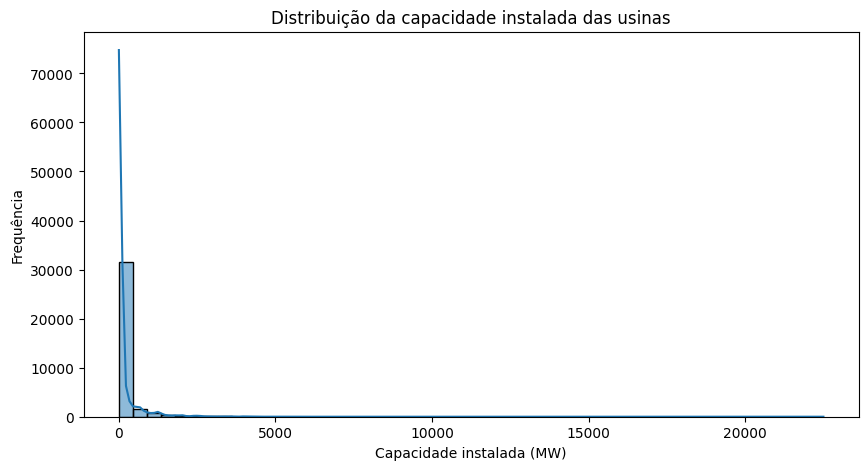

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(df['capacity_mw'], bins=50, kde=True)
plt.title('Distribuição da capacidade instalada das usinas')
plt.xlabel('Capacidade instalada (MW)')
plt.ylabel('Frequência')
plt.show()

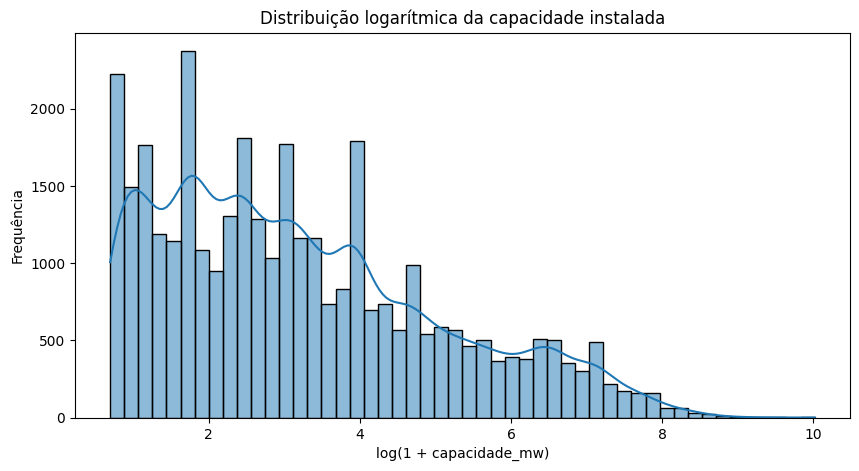

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['capacity_mw']), bins=50, kde=True)
plt.title('Distribuição logarítmica da capacidade instalada')
plt.xlabel('log(1 + capacidade_mw)')
plt.ylabel('Frequência')
plt.show()

A transformação logarítmica é útil para visualizar melhor variáveis muito assimétricas. Ela reduz o impacto visual de valores muito altos.

### 6.2- Boxplot da capacidade instalada

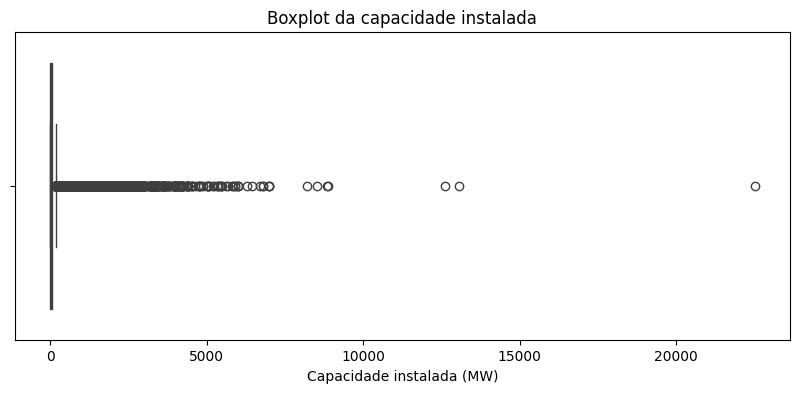

In [41]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['capacity_mw'])
plt.title('Boxplot da capacidade instalada')
plt.xlabel('Capacidade instalada (MW)')
plt.show()

O boxplot evidencia a presença de outliers, principalmente usinas com capacidade muito acima da maioria das observações.

### 6.3- Quantidade de usinas por fonte primária de energia

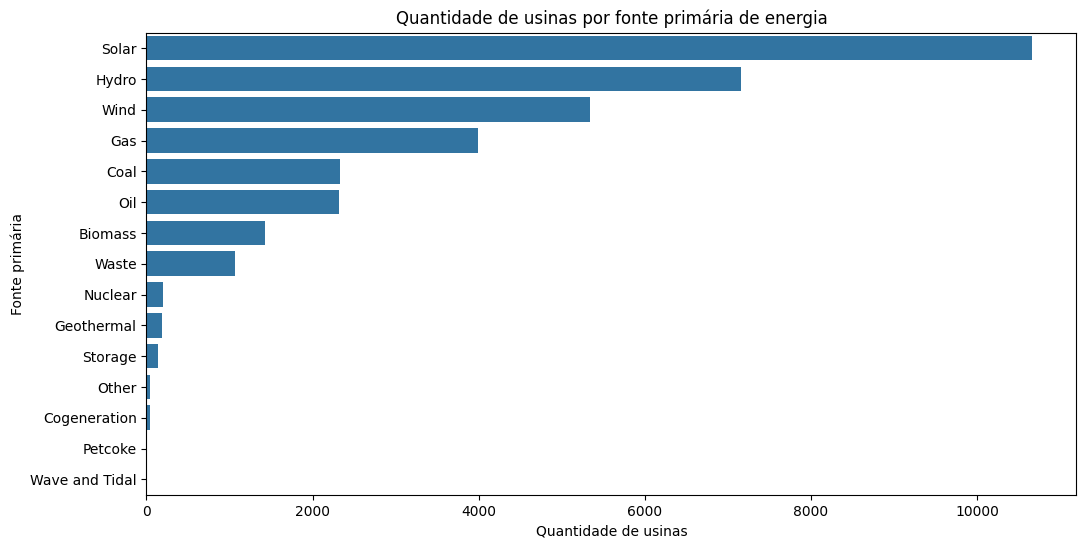

In [42]:
plt.figure(figsize=(12, 6))
ordem = df['primary_fuel'].value_counts().index
sns.countplot(data=df, y='primary_fuel', order=ordem)
plt.title('Quantidade de usinas por fonte primária de energia')
plt.xlabel('Quantidade de usinas')
plt.ylabel('Fonte primária')
plt.show()

### 6.4- Capacidade média por fonte primária de energia

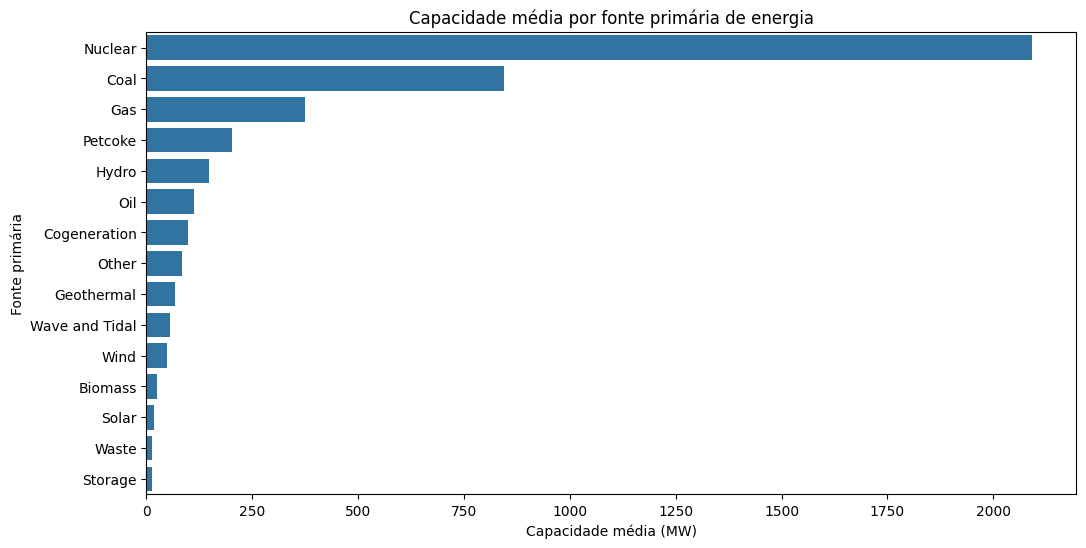

In [43]:
capacidade_por_fonte = (
    df.groupby('primary_fuel')['capacity_mw']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=capacidade_por_fonte.values, y=capacidade_por_fonte.index)
plt.title('Capacidade média por fonte primária de energia')
plt.xlabel('Capacidade média (MW)')
plt.ylabel('Fonte primária')
plt.show()

### 6.5- Scatterplot: latitude, longitude e capacidade
O gráfico abaixo permite observar a distribuição geográfica das usinas. O tamanho dos pontos representa a capacidade instalada.

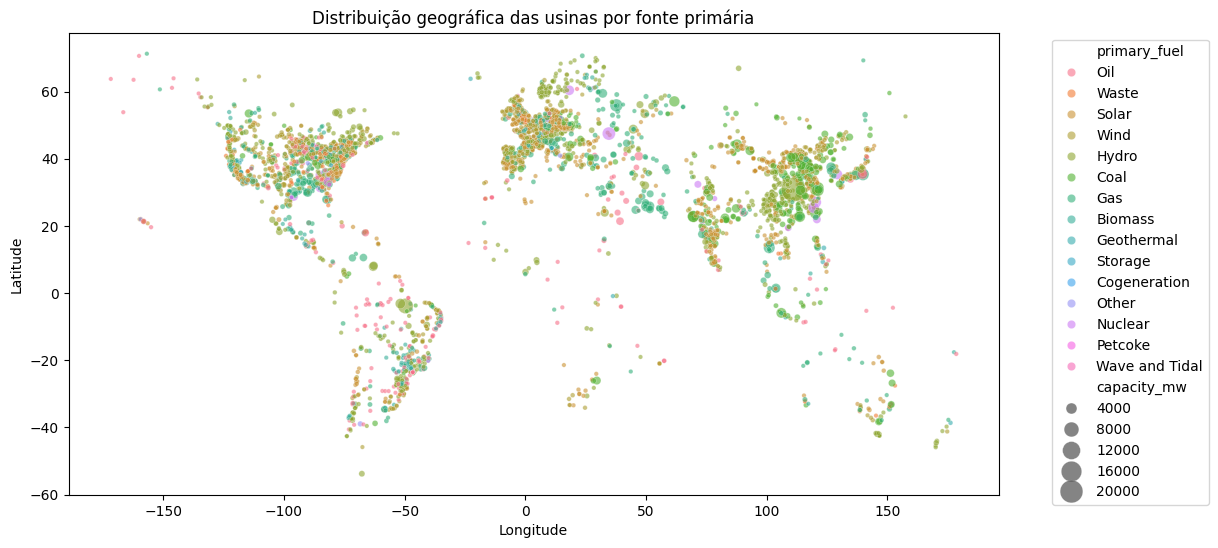

In [44]:
amostra_geo = df.sample(min(5000, len(df)), random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=amostra_geo,
    x='longitude',
    y='latitude',
    size='capacity_mw',
    hue='primary_fuel',
    alpha=0.6,
    sizes=(10, 300)
)
plt.title('Distribuição geográfica das usinas por fonte primária')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 6.5.1- Usinas Nucleares no Hemisfério Sul
*Apenas compartilhando uma curiosidade notada ao explorar o data set.*

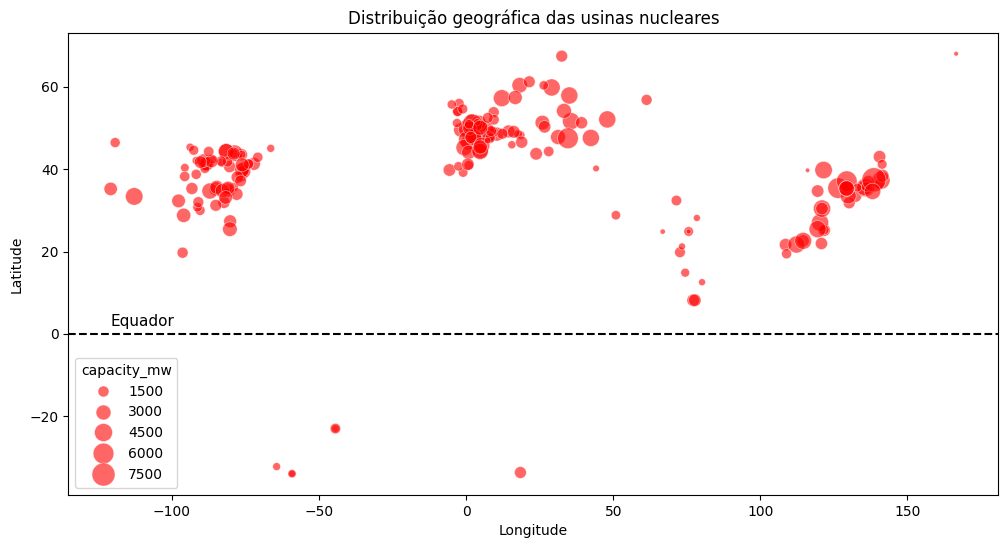

In [45]:
df_nuclear = df[df['primary_fuel'] == 'Nuclear']

amostra_geo = df_nuclear.sample(
    min(5000, len(df_nuclear)),
    random_state=42
)

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=amostra_geo,
    x='longitude',
    y='latitude',
    size='capacity_mw',
    alpha=0.6,
    sizes=(10, 300),
    color='red'
)

# Linha do Equador
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1.5
)
plt.text(
    x=amostra_geo['longitude'].min(),
    y=2,
    s='Equador',
    fontsize=11,
    color='black'
)

plt.title('Distribuição geográfica das usinas nucleares')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 6.6- Heatmap de correlação
O heatmap mostra a relação linear entre variáveis numéricas. Valores próximos de 1 indicam correlação positiva forte, valores próximos de -1 indicam correlação negativa forte e valores próximos de 0 indicam baixa correlação linear.

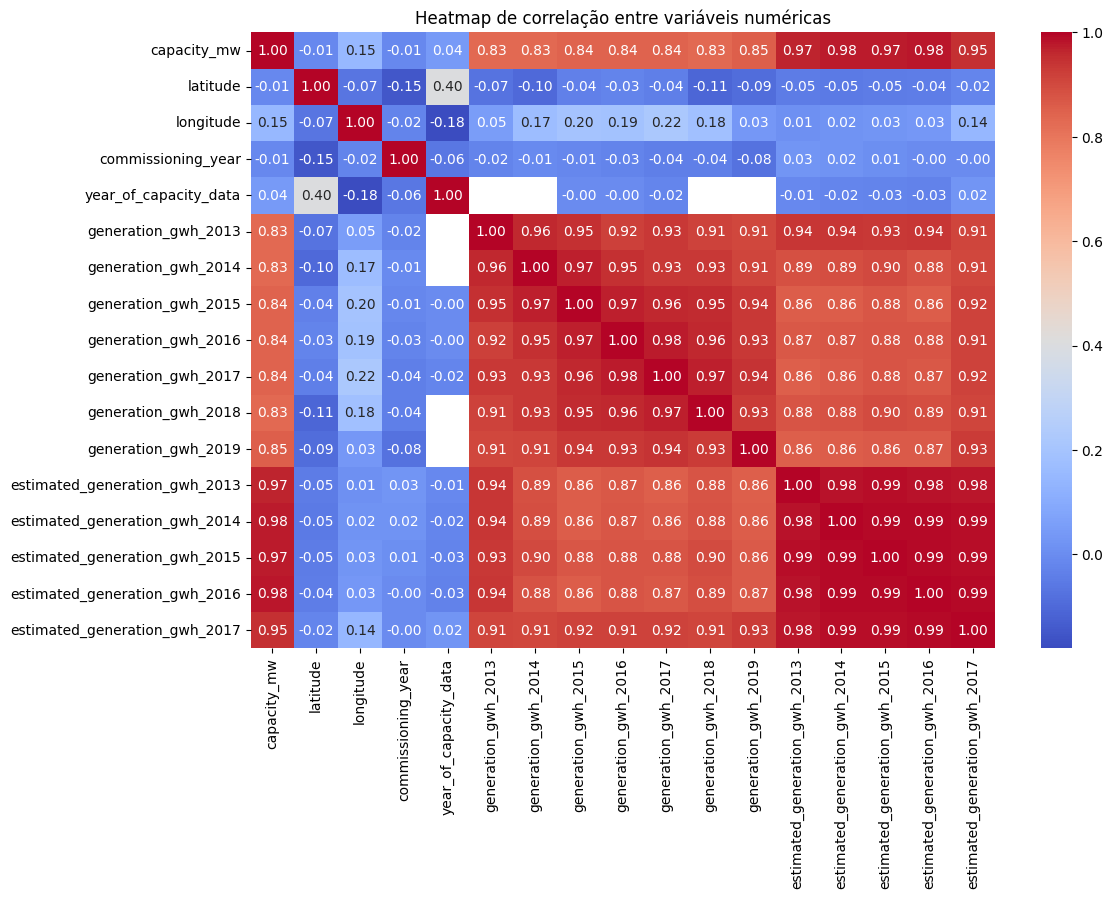

In [46]:
colunas_numericas = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de correlação entre variáveis numéricas')
plt.show()

## 7- Tratamento de outliers
A variável `capacity_mw` apresenta valores extremos. Como a capacidade instalada é a variável alvo, remover automaticamente todos os outliers poderia eliminar justamente usinas importantes do mundo real.

Neste projeto, será feito um tratamento conservador:

* remover registros com `capacity_mw` ausente ou menor/igual a zero;
* aplicar uma transformação logarítmica na variável alvo durante a modelagem;
* manter valores extremos plausíveis, pois eles representam usinas reais de grande porte.

Essa decisão evita perda excessiva de informação.

In [47]:
# Removendo registros sem alvo válido
antes = df.shape[0]
df = df[df['capacity_mw'].notna()].copy()
df = df[df['capacity_mw'] > 0].copy()
depois = df.shape[0]

print(f'Registros antes: {antes}')
print(f'Registros depois: {depois}')
print(f'Registros removidos: {antes - depois}')

Registros antes: 34936
Registros depois: 34936
Registros removidos: 0


## 8- Engenharia de atributos
Neste projeto serão criados atributos derivados dos dados originais. São eles:

1. `is_renewable`: indica se a fonte primária da usina é renovável;
2. `plant_age`: idade aproximada da usina com base no ano de comissionamento;
3. `capacity_category`: categoria de porte da usina, criada a partir da capacidade instalada.

> **Observação importante**: `capacity_category` é derivada da variável alvo. Por isso, ela será usada apenas na análise exploratória e não será usada como variável preditora no modelo, pois causaria **data leakage**.

In [48]:
fontes_renovaveis = ['Hydro', 'Wind', 'Solar', 'Biomass', 'Geothermal', 'Wave', 'Storage']

df['is_renewable'] = df['primary_fuel'].isin(fontes_renovaveis).astype(int)

df['plant_age'] = 2026 - df['commissioning_year']
df.loc[df['plant_age'] < 0, 'plant_age'] = np.nan

df['capacity_category'] = pd.cut(
    df['capacity_mw'],
    bins=[0, 50, 500, 2000, np.inf],
    labels=['Pequena', 'Média', 'Grande', 'Muito grande']
)

df[['primary_fuel', 'is_renewable', 'commissioning_year', 'plant_age', 'capacity_mw', 'capacity_category']].head()

,primary_fuel,is_renewable,commissioning_year,plant_age,capacity_mw,capacity_category
0,Hydro,1,NaN,NaN,33.0,Pequena
1,Solar,1,NaN,NaN,10.0,Pequena
2,Solar,1,NaN,NaN,10.0,Pequena
3,Hydro,1,NaN,NaN,66.0,Média
4,Hydro,1,NaN,NaN,100.0,Média


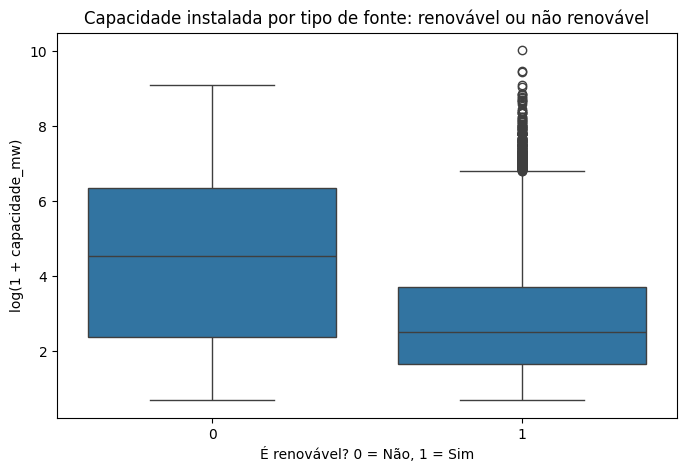

In [49]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_renewable', y=np.log1p(df['capacity_mw']))
plt.title('Capacidade instalada por tipo de fonte: renovável ou não renovável')
plt.xlabel('É renovável? 0 = Não, 1 = Sim')
plt.ylabel('log(1 + capacidade_mw)')
plt.show()

Após a criação da variável `is_renewable`, observa-se que as usinas classificadas como não renováveis apresentam, em geral, maior capacidade instalada em comparação às renováveis. A mediana do grupo não renovável é superior, e sua distribuição é mais ampla, indicando maior presença de usinas de grande porte. Já as usinas renováveis concentram-se em capacidades menores, embora existam outliers relevantes, possivelmente associados a grandes empreendimentos hidrelétricos, eólicos ou solares. Essa diferença sugere que a variável `is_renewable` pode ser útil para o modelo, pois ajuda a distinguir padrões de capacidade entre fontes energéticas.

## 9- Prevenção de Data Leakage
**Data leakage** ocorre quando informações que não estariam disponíveis no momento da previsão acabam sendo usadas no treinamento do modelo. Isso gera resultados artificialmente bons, mas que não se sustentam em dados reais.

Neste projeto, algumas decisões foram tomadas para evitar leakage:

* a variável alvo `capacity_mw` não será usada como atributo preditor;
* o atributo `capacity_category`, por ser derivado da variável alvo, não será usado no modelo;
* colunas de geração estimada, quando existirem, serão removidas, pois podem estar fortemente relacionadas à capacidade da usina;
imputação, codificação e escalonamento serão feitos dentro de um `Pipeline`, ajustado somente com dados de treino em cada etapa de validação.

O uso de `Pipeline` e `ColumnTransformer` ajuda a prevenir leakage porque as transformações são aprendidas apenas no conjunto de treino e depois aplicadas ao teste.

## 10- Seleção de variáveis
Serão utilizadas variáveis numéricas e categóricas disponíveis antes da previsão da capacidade instalada.

Colunas relacionadas diretamente à geração de energia serão removidas para reduzir risco de data leakage.

In [50]:
# Colunas que podem causar leakage ou que não são úteis para previsão geral
colunas_remover = [
    'capacity_mw',
    'capacity_category',
    'estimated_generation_gwh',
    'estimated_generation_gwh_2013',
    'estimated_generation_gwh_2014',
    'estimated_generation_gwh_2015',
    'estimated_generation_gwh_2016',
    'estimated_generation_gwh_2017',
    'generation_gwh_2013',
    'generation_gwh_2014',
    'generation_gwh_2015',
    'generation_gwh_2016',
    'generation_gwh_2017',
    'generation_gwh_2018',
    'generation_gwh_2019',
    'generation_data_source',
    'wepp_id',
    'gppd_idnr',
    'name'
]

colunas_existentes_remover = [col for col in colunas_remover if col in df.columns]

X = df.drop(columns=colunas_existentes_remover)
y = np.log1p(df['capacity_mw'])

print('Colunas removidas:')
print(colunas_existentes_remover)
print('Formato de X:', X.shape)
print('Formato de y:', y.shape)

Colunas removidas:
['capacity_mw', 'capacity_category', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'wepp_id', 'gppd_idnr', 'name']
Formato de X: (34936, 21)
Formato de y: (34936,)


In [51]:
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print('Variáveis numéricas:')
print(num_features)
print('Variáveis categóricas:')
print(cat_features)

Variáveis numéricas:
['latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data', 'is_renewable', 'plant_age']
Variáveis categóricas:
['country', 'country_long', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'owner', 'source', 'url', 'geolocation_source', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


## 11- Divisão treino/teste
A divisão treino/teste permite avaliar o desempenho do modelo em dados que não foram utilizados no treinamento.

Será utilizada a proporção:

80% para treino;
20% para teste.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (27948, 21)
Teste: (6988, 21)


## 12- Pipeline de pré-processamento
Serão aplicadas transformações diferentes para variáveis numéricas e categóricas.

Para variáveis numéricas:

* imputação pela mediana$^1$;
* padronização com `StandardScaler`.

Para variáveis categóricas:

* imputação pela moda$^2$;
* codificação com `OneHotEncoder`.

$^1$A mediana foi escolhida para variáveis numéricas porque é mais robusta à presença de outliers.

$^2$Para categóricas, a moda representa a categoria mais frequente.

In [58]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

## 13- Modelo escolhido
Foi escolhido o algoritmo `KNeighborsRegressor`.

O KNN para regressão prevê o valor de uma nova observação com base nos valores das observações mais próximas no conjunto de treino.

Principais parâmetros:

* `n_neighbors`: quantidade de vizinhos considerados;
* `weights`: forma de ponderação dos vizinhos;
* `p`: métrica de distância, sendo `p=1` distância Manhattan e `p=2` distância Euclidiana.

Como o KNN depende de distâncias, o escalonamento das variáveis numéricas é importante.

In [59]:
model = KNeighborsRegressor()

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'commissioning_year',
                                                   'year_of_capacity_data',
                                                   'is_renewable',
                                                   'plant_age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHo...
                                                                                 sparse_output=False))]),
                                                  ['country', 'country_long',
                                                   'primary_fuel',
                                                   'other_fuel1', 'other_fuel2',
                                                   'other_fuel3', 'owner',
                                                   'source', 'url',
                                                   'geolocation_source',
                                                   'estimated_generation_note_2013',
                                                   'estimated_generation_note_2014',
                                                   'estimated_generation_note_2015',
                                                   'estimated_generation_note_2016',
                                                   'estimated_generation_note_2017'])])),
                ('model', KNeighborsRegressor())])

## 14- Validação com K-Fold Cross Validation
O K-Fold divide os dados de treino em K partes. Em cada rodada, uma parte é usada para validação e as demais para treinamento. Esse processo permite avaliar o desempenho médio do modelo de forma mais estável do que uma única divisão treino/teste.

Neste projeto será utilizado `KFold` com 3 divisões.

*Testei com `k=5`, mas durou mais de 3horas.*

In [60]:
# K-Fold reduzido para deixar o processamento mais leve
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

scores_mae = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring='neg_mean_absolute_error'
)

mae_scores = -scores_mae

print('MAE em cada fold:', mae_scores)
print('MAE médio:', mae_scores.mean())
print('Desvio padrão do MAE:', mae_scores.std())

MAE em cada fold: [0.75404854 0.75512004 0.75135539]
MAE médio: 0.753507988884608
Desvio padrão do MAE: 0.001583728792261798


Como a variável alvo foi transformada com `log1p`, o MAE acima está na escala logarítmica. A avaliação final no conjunto de teste será convertida novamente para megawatts.

## 15- GridSearchCV

O `GridSearchCV` testa diferentes combinações de hiperparâmetros e utiliza validação cruzada para selecionar a melhor combinação.

Parâmetros testados:

* `model__n_neighbors`: quantidade de vizinhos;
* `model__weights`: peso uniforme ou ponderado pela distância;
* `model__p`: tipo de distância utilizada.

In [61]:
param_grid = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['distance'],
    'model__p': [2]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Melhores parâmetros encontrados:')
print(grid_search.best_params_)

print('Melhor MAE médio em validação cruzada, escala log:')
print(-grid_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros encontrados:
{'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}
Melhor MAE médio em validação cruzada, escala log:
0.7300291927185466


In [62]:
resultados_grid = pd.DataFrame(grid_search.cv_results_)
resultados_grid[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head(10)

,params,mean_test_score,std_test_score,rank_test_score
2,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",-0.730029,0.001550,1
1,"{'model__n_neighbors': 5, 'model__p': 2, 'mode...",-0.734547,0.003030,2
0,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",-0.754848,0.001851,3


## 16- Avaliação no conjunto de teste

Após escolher os melhores hiperparâmetros com validação cruzada, o modelo final é avaliado no conjunto de teste.

Como a variável alvo foi treinada em escala logarítmica, as previsões são convertidas de volta para megawatts com `expm1`.

In [75]:
# Pegando o melhor modelo encontrado pelo GridSearchCV
best_model = grid_search.best_estimator_

# Fazendo previsões no conjunto de teste em escala logarítmica
y_pred_log = best_model.predict(X_test)

# Voltando para a escala original: MW
y_test_mw = np.expm1(y_test)
y_pred_mw = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_mw, y_pred_mw)
rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
r2 = r2_score(y_test_mw, y_pred_mw)

print(f'MAE: {mae:.2f} MW')
print(f'RMSE: {rmse:.2f} MW')
print(f'R²: {r2:.4f}')

MAE: 108.67 MW
RMSE: 433.54 MW
R²: 0.3441


* MAE: erro médio em MW.
* RMSE: erro que penaliza mais previsões muito erradas.
* R²: quanto o modelo explica da variação dos dados.

In [82]:
comparacao = pd.DataFrame({
    'valor_real_mw': y_test_mw.values,
    'valor_previsto_mw': y_pred_mw
})

comparacao['erro_absoluto_mw'] = abs(comparacao['valor_real_mw'] - comparacao['valor_previsto_mw'])
comparacao.head(10)

,valor_real_mw,valor_previsto_mw,erro_absoluto_mw
0,2.65000,1.723216,0.926784
1,3.60000,34.383727,30.783727
2,4.00000,11.992119,7.992119
3,1.80000,1.954945,0.154945
4,16.50000,22.978777,6.478777
5,460.00000,52.968092,407.031908
6,4.79070,1.972377,2.818323
7,4.63197,7.229631,2.597661
8,40.00000,41.290031,1.290031
9,263.00000,1809.063323,1546.063323


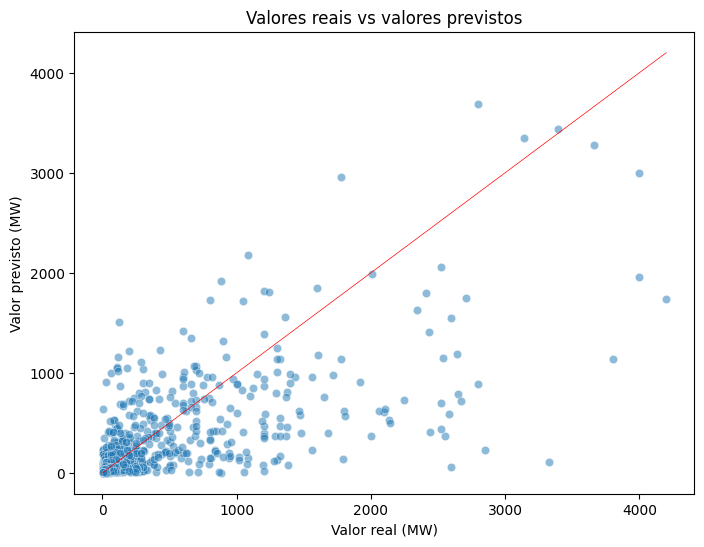

In [83]:
plt.figure(figsize=(8, 6))

amostra_plot = comparacao.sample(min(2000, len(comparacao)), random_state=42)

sns.scatterplot(
    data = amostra_plot,
    x='valor_real_mw',
    y='valor_previsto_mw',
    alpha=0.5
)

# Reta y = x
plt.plot(
    [amostra_plot['valor_real_mw'].min(), amostra_plot['valor_real_mw'].max()],
    [amostra_plot['valor_real_mw'].min(), amostra_plot['valor_real_mw'].max()],
    linestyle='-',
    linewidth=0.5,
    color='red'
)

plt.title('Valores reais vs valores previstos')
plt.xlabel('Valor real (MW)')
plt.ylabel('Valor previsto (MW)')
plt.show()

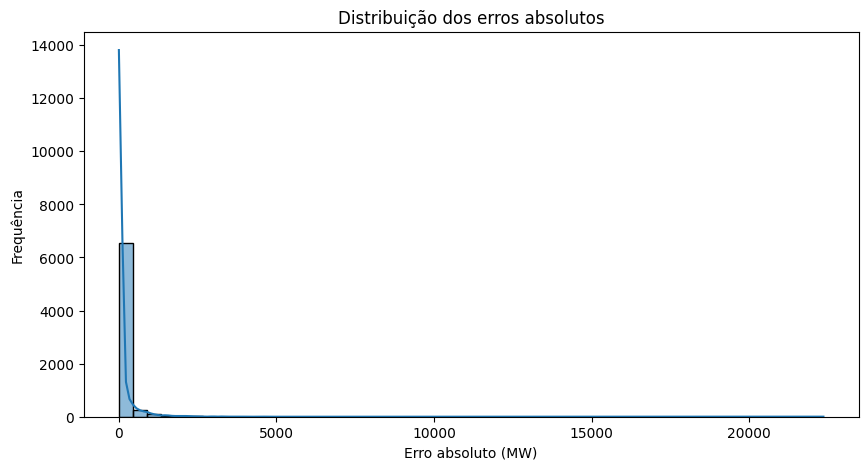

In [84]:
plt.figure(figsize=(10, 5))
sns.histplot(comparacao['erro_absoluto_mw'], bins=50, kde=True)
plt.title('Distribuição dos erros absolutos')
plt.xlabel('Erro absoluto (MW)')
plt.ylabel('Frequência')
plt.show()

O histograma dos erros absolutos mostra que a maior parte dos erros está concentrada em valores baixos, próxima de zero. Isso indica que o modelo consegue prever razoavelmente bem a capacidade instalada de muitas usinas.

No entanto, a distribuição apresenta uma cauda longa à direita, com alguns erros muito elevados. Isso sugere que o modelo tem maior dificuldade para prever usinas com capacidade muito alta, provavelmente por serem casos extremos ou menos frequentes no dataset.

Portanto, o desempenho geral do modelo parece aceitável para a maioria das usinas, mas ainda apresenta limitações em previsões de grandes usinas ou casos fora do padrão.

## 17- Discussão dos resultados
O modelo conseguiu construir uma estimativa da capacidade instalada das usinas a partir de informações como localização, fonte primária, país, proprietário e idade aproximada da planta.

O pré-processamento teve impacto importante porque:

* o dataset possui valores ausentes;
* há variáveis categóricas que precisaram ser codificadas;
* o KNN depende de distância, então o escalonamento foi necessário;
* a variável alvo possui forte assimetria, justificando a transformação logarítmica.

A engenharia de atributos ajudou a representar melhor algumas características do problema, especialmente a distinção entre fontes renováveis e não renováveis e a idade aproximada da usina.

### 17.1- Dificuldades encontradas
Algumas dificuldades naturais deste dataset são:

* grande quantidade de valores ausentes em algumas colunas;
* presença de outliers reais, como usinas de capacidade muito elevada;
* alta cardinalidade em variáveis como `owner`, `source` e `country`;
* risco de data leakage em colunas relacionadas à geração de energia;
* diferenças estruturais entre países, fontes de energia e formas de coleta dos dados.

### 17.2- Limitações do dataset
Apesar de ser amplo, o dataset apresenta limitações:

* nem todas as usinas possuem informações completas;
* algumas informações podem estar desatualizadas;
* a capacidade instalada não depende apenas das variáveis disponíveis;
* fatores econômicos, tecnológicos, regulatórios e históricos não estão completamente representados;
* a qualidade dos dados pode variar entre países.

### 17.3- Possíveis melhorias futuras
Possíveis melhorias incluem:

* testar modelos adicionais, como Random Forest, Gradient Boosting ou XGBoost;
* realizar seleção de atributos;
* tratar variáveis categóricas de alta cardinalidade com técnicas específicas;
* utilizar validação por país ou região;
* enriquecer os dados com indicadores econômicos, climáticos ou populacionais;
* criar atributos geográficos mais elaborados.


## 18- Conclusão
O projeto demonstrou a construção de um fluxo completo de Ciência de Dados para um problema de regressão supervisionada.

Foram aplicadas etapas de análise exploratória, tratamento de dados, engenharia de atributos, transformação de variáveis, modelagem, validação cruzada, otimização de hiperparâmetros e avaliação final.

O uso de `Pipeline` e `ColumnTransformer` organizou o processo e ajudou a prevenir data leakage, garantindo que as transformações fossem ajustadas corretamente apenas nos dados de treino.